In [ ]:
import pandas as pd
import numpy as np
import zipfile

with zipfile.ZipFile('detective.zip') as zip_ref:
    zip_ref.extractall()

test_df = pd.read_csv('test_data.csv')
test_df.head(3)

,subtaskID,datapointID,f_naming_camel_ratio,f_naming_snake_ratio,f_naming_single_char_ratio,f_naming_avg_length,f_indent_tab_ratio,f_indent_2space_ratio,f_indent_4space_ratio,f_indent_mixed_ratio,...,f_struct_avg_func_length,f_struct_avg_block_depth,f_struct_import_count,f_struct_class_ratio,f_literal_magic_num_ratio,f_literal_string_ratio,f_literal_fstring_ratio,f_ctrl_for_vs_while,f_ctrl_if_else_ratio,f_ctrl_ternary_ratio
0,1,1324636578,0.478350,0.440615,0.233303,10.294964,0.829591,0.277773,0.578284,0.118437,...,29.483793,3.523624,18.313917,0.317231,0.102571,0.150000,0.041096,0.848397,0.484024,0.100000
1,1,227854337,0.844751,0.149255,0.462381,14.685766,0.049621,1.000000,0.000000,0.000000,...,40.000000,3.053644,1.000000,0.000000,0.134809,0.018074,0.497529,1.000000,0.602129,0.066492
2,1,869491723,0.270948,0.217354,0.072720,15.000000,0.635907,0.218743,0.350560,0.300000,...,24.930503,2.004381,6.754038,0.000000,0.130266,0.062495,0.000000,0.500000,0.547036,0.028547


In [2]:
cols_to_drop = ['subtaskID', 'datapointID']
features = test_df.drop(cols_to_drop, axis=1).columns

X_test = test_df[features]

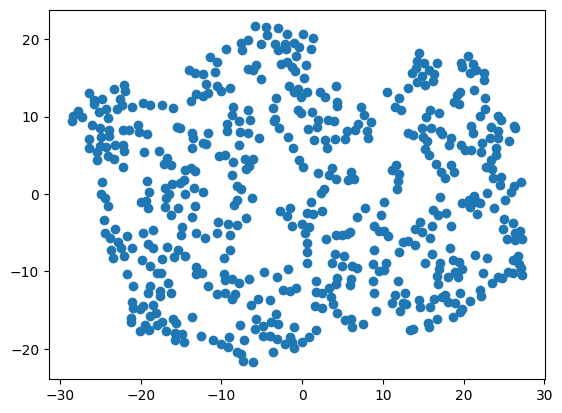

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

xy = TSNE(2, random_state=42).fit_transform(X_test)

plt.scatter(x=xy[:, 0], y=xy[:, 1])
plt.show()

In [4]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

X_test_scaled = StandardScaler().fit_transform(X_test)

results = []

K_range = range(2, 151)

for k in K_range:
    kmeans = KMeans(k, random_state=42, n_init=30)
    labels = kmeans.fit_predict(X_test_scaled)

    score = silhouette_score(X_test_scaled, labels)
    results.append((k, score))

#Sort by score (descending)
results.sort(key=lambda x: x[1], reverse=True)

#Print top 5
top_5 = results[:5]

for k, score in top_5:
    print(f'k = {k}, silhouette score = {score:.4f}')

k = 89, silhouette score = 0.1181
k = 84, silhouette score = 0.1175
k = 87, silhouette score = 0.1169
k = 113, silhouette score = 0.1169
k = 93, silhouette score = 0.1166


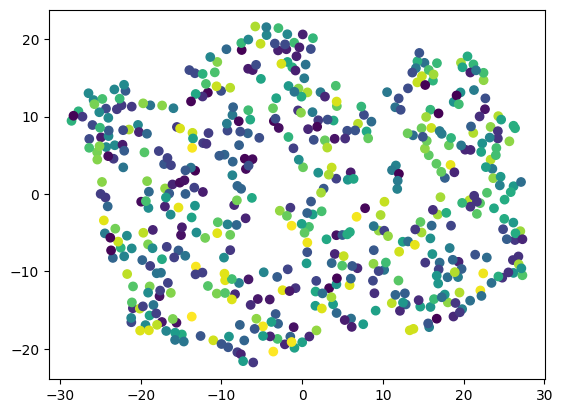

In [ ]:
clusterer = KMeans(n_clusters=113, random_state=42, n_init=30)  #Works the best
test_labels = clusterer.fit_predict(X_test_scaled)

plt.scatter(x=xy[:, 0], y=xy[:, 1], c=test_labels)
plt.show()

In [6]:
output_df = pd.DataFrame({
    'subtaskID':1,
    'datapointID':test_df['datapointID'],
    'answer':test_labels
})

output_df.to_csv('submission.csv', index=False)
output_df.head()

,subtaskID,datapointID,answer
0,1,1324636578,90
1,1,227854337,59
2,1,869491723,87
3,1,996965456,11
4,1,217696908,92


This solution gets 70/100;

When I'll find a better solution I'll update the notebook.